In [40]:
from google.colab import files
print("upload kaggle.json")
uploaded = files.upload()

upload kaggle.json


Saving kaggle (1).json to kaggle (1) (1).json


In [41]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p /content/data/ --unzip

print("dataset downloaded")

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:10<00:00, 15.2MB/s]

dataset downloaded


In [42]:
import os
import glob
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.utils import to_categorical

In [43]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [44]:
DATASET_PATH = "/content/data/Training"

IMG_SIZE = 128

CLASSES = [
    "notumor",
    "glioma",
    "meningioma",
    "pituitary"
]

In [45]:
def load_images(class_name, label):

    folder = os.path.join(DATASET_PATH, class_name)

    image_paths = sorted(
        glob.glob(os.path.join(folder, "*.jpg")) +
        glob.glob(os.path.join(folder, "*.png")) +
        glob.glob(os.path.join(folder, "*.jpeg"))
    )

    images = []
    labels = []

    for path in image_paths:

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype(np.float32) / 255.0

        images.append(img)
        labels.append(label)

    return np.array(images), np.array(labels)

In [46]:
X = []
y = []

for label, class_name in enumerate(CLASSES):

    print(f"Loading {class_name} ...")

    images, labels = load_images(class_name, label)

    X.extend(images)
    y.extend(labels)

    print(f"Loaded {len(images)} images")

X = np.array(X)
y = np.array(y)

# Add channel dimension
X = X[..., np.newaxis]

print("\nDataset Loaded Successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Loading notumor ...
Loaded 1400 images
Loading glioma ...
Loaded 1400 images
Loading meningioma ...
Loaded 1400 images
Loading pituitary ...
Loaded 1400 images

Dataset Loaded Successfully!
X shape: (5600, 128, 128, 1)
y shape: (5600,)


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
    shuffle=True
)

print("Training images :", X_train.shape)
print("Testing images  :", X_test.shape)

Training images : (4480, 128, 128, 1)
Testing images  : (1120, 128, 128, 1)


In [48]:
print("Training Set")

for i, name in enumerate(CLASSES):
    print(f"{name:12s}: {(y_train==i).sum()}")

print("\nTesting Set")

for i, name in enumerate(CLASSES):
    print(f"{name:12s}: {(y_test==i).sum()}")

Training Set
notumor     : 1120
glioma      : 1120
meningioma  : 1120
pituitary   : 1120

Testing Set
notumor     : 280
glioma      : 280
meningioma  : 280
pituitary   : 280


In [49]:
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=4)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=4)

print(y_train_cat.shape)
print(y_test_cat.shape)

(4480, 4)
(1120, 4)


In [50]:
print("="*50)
print("Dataset Summary")
print("="*50)

print(f"Total Images : {len(X)}")
print(f"Image Shape  : {X.shape[1:]}")
print(f"Number of Classes : {len(CLASSES)}")

for i, cls in enumerate(CLASSES):
    print(f"{cls:12s}: {(y==i).sum()}")

Dataset Summary
Total Images : 5600
Image Shape  : (128, 128, 1)
Number of Classes : 4
notumor     : 1400
glioma      : 1400
meningioma  : 1400
pituitary   : 1400


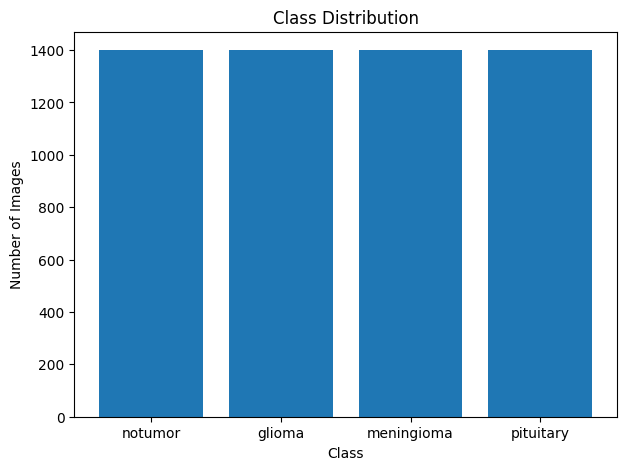

In [51]:
counts = [np.sum(y == i) for i in range(len(CLASSES))]

plt.figure(figsize=(7,5))
plt.bar(CLASSES, counts)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

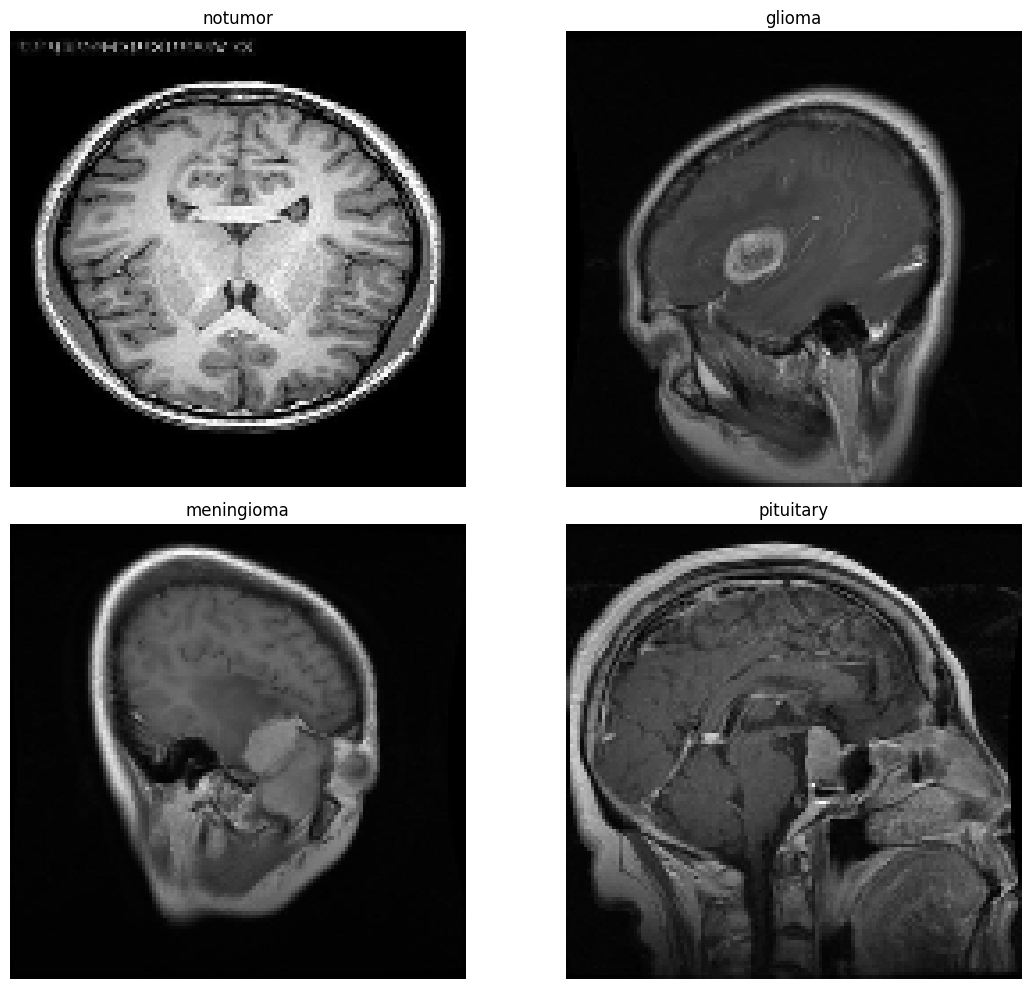

In [52]:
plt.figure(figsize=(12,10))

for i, cls in enumerate(CLASSES):

    idx = np.random.choice(np.where(y == i)[0])

    plt.subplot(2,2,i+1)
    plt.imshow(X[idx].squeeze(), cmap="gray")
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

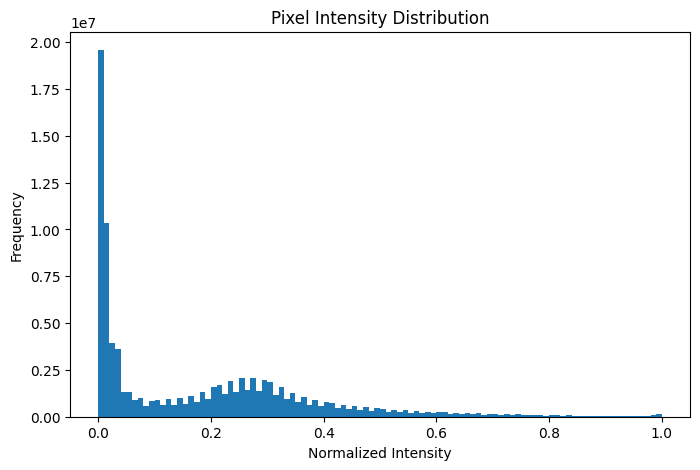

In [53]:
plt.figure(figsize=(8,5))

plt.hist(
    X.flatten(),
    bins=100
)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Normalized Intensity")
plt.ylabel("Frequency")

plt.show()

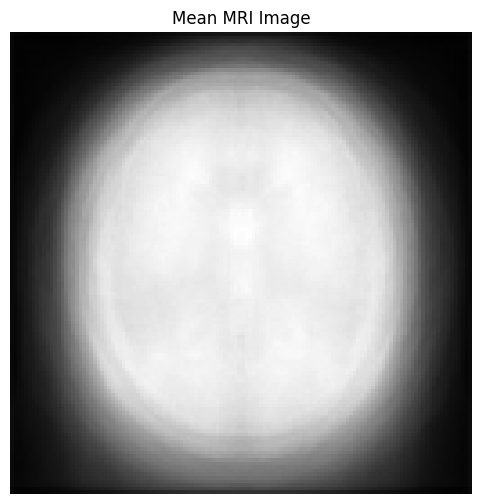

In [54]:
mean_image = np.mean(X, axis=0)

plt.figure(figsize=(6,6))
plt.imshow(mean_image.squeeze(), cmap="gray")
plt.title("Mean MRI Image")
plt.axis("off")

plt.show()

In [55]:
print("Minimum pixel :", np.min(X))
print("Maximum pixel :", np.max(X))
print("Mean pixel    :", np.mean(X))
print("Std pixel     :", np.std(X))

Minimum pixel : 0.0
Maximum pixel : 1.0
Mean pixel    : 0.18410166
Std pixel     : 0.19923088


In [56]:
unique_shapes = set(img.shape for img in X)

print(unique_shapes)

{(128, 128, 1)}


In [57]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.08),

    layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    ),

], name="data_augmentation")

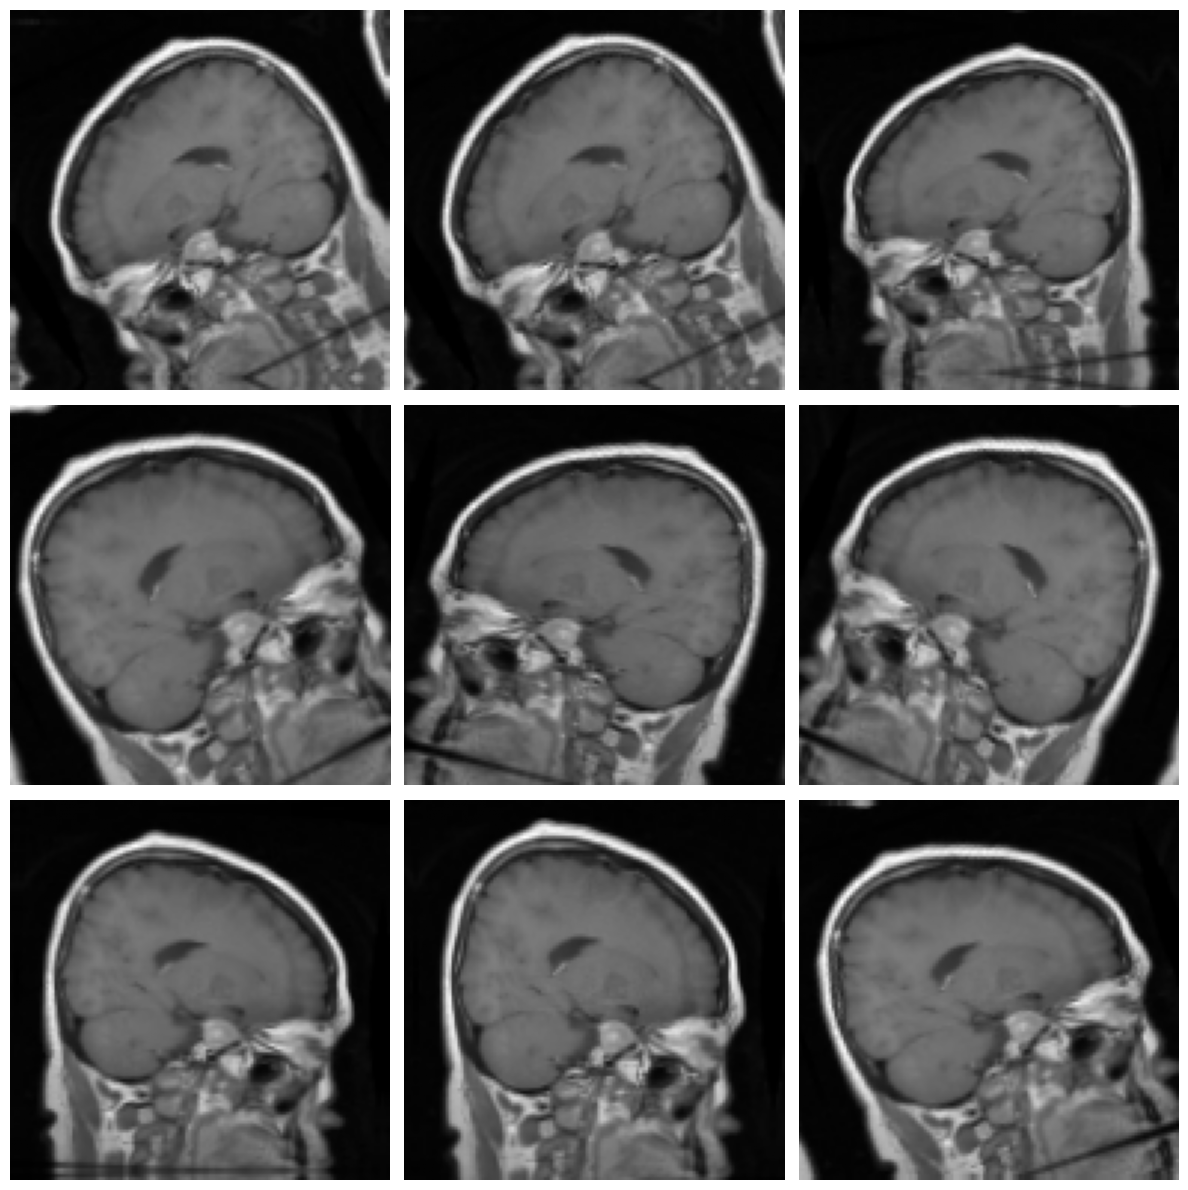

In [58]:
sample = X_train[0]

plt.figure(figsize=(12,12))

for i in range(9):

    augmented = data_augmentation(
        tf.expand_dims(sample, 0),
        training=True
    )

    plt.subplot(3,3,i+1)
    plt.imshow(
        augmented[0].numpy().squeeze(),
        cmap="gray"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [59]:
baseline_model = tf.keras.Sequential([

    layers.Input(shape=(128, 128, 1)),

    data_augmentation,

    layers.Conv2D(
        32,
        (3,3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3,3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3,3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(),

    layers.Conv2D(
        256,
        (3,3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        4,
        activation="softmax"
    )

])

baseline_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,583,428 (17.48 MB)

 Trainable params: 4,583,428 (17.48 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
baseline_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)

In [61]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True

)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=4,

    verbose=1

)

In [62]:
history = baseline_model.fit(

    X_train,

    y_train_cat,

    validation_split=0.2,

    epochs=40,

    batch_size=32,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1

)

Epoch 1/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.5871 - loss: 0.9599 - val_accuracy: 0.6853 - val_loss: 0.8078 - learning_rate: 0.0010
Epoch 2/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7358 - loss: 0.6596 - val_accuracy: 0.7288 - val_loss: 0.7311 - learning_rate: 0.0010
Epoch 3/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7863 - loss: 0.5549 - val_accuracy: 0.6864 - val_loss: 0.7889 - learning_rate: 0.0010
Epoch 4/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8019 - loss: 0.5099 - val_accuracy: 0.7400 - val_loss: 0.6912 - learning_rate: 0.0010
Epoch 5/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8376 - loss: 0.4482 - val_accuracy: 0.6116 - val_loss: 1.0704 - learning_rate: 0.0010
Epoch 6/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8524 - loss: 0.4029 - val_accuracy: 0.6306 - val_loss: 0.9670 - learning_rate: 0.0010
Epoch 7/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8758 - loss: 0.

In [63]:
print(X_test.shape)

print(y_test.shape)

print(type(X_test), type(y_test))

(1120, 128, 128, 1)
(1120,)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [64]:
baseline_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)

test_loss, test_acc = baseline_model.evaluate(
    X_test,
    y_test_cat,
    verbose=1
)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9411 - loss: 0.1770
Test Accuracy: 0.9411
Test Loss: 0.1770


In [65]:
y_pred_prob = baseline_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [67]:
class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

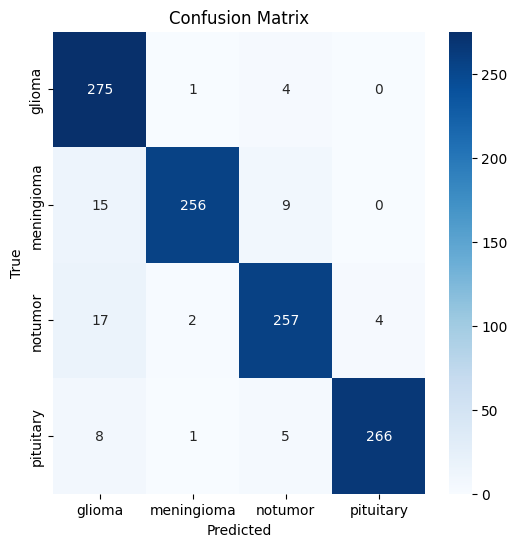

In [68]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [69]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.87      0.98      0.92       280
  meningioma       0.98      0.91      0.95       280
     notumor       0.93      0.92      0.93       280
   pituitary       0.99      0.95      0.97       280

    accuracy                           0.94      1120
   macro avg       0.94      0.94      0.94      1120
weighted avg       0.94      0.94      0.94      1120



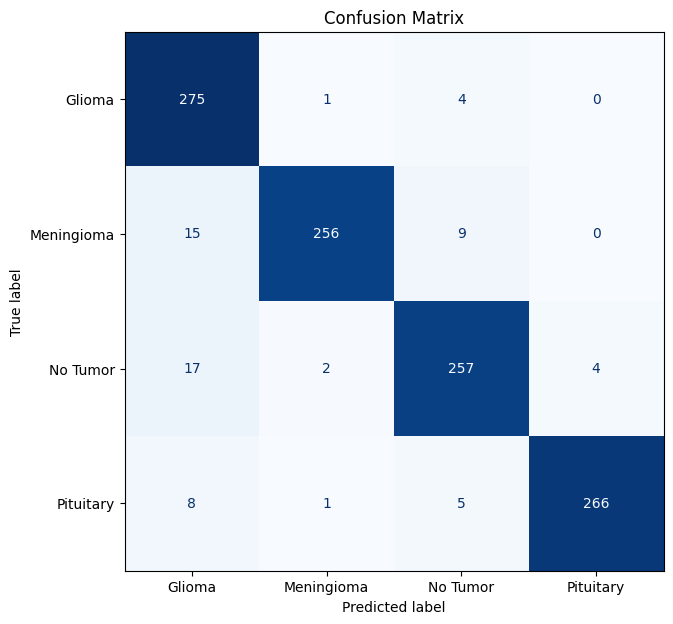

In [70]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

class_names = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names)

fig, ax = plt.subplots(figsize=(7,7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.show()

Number of misclassified images: 66


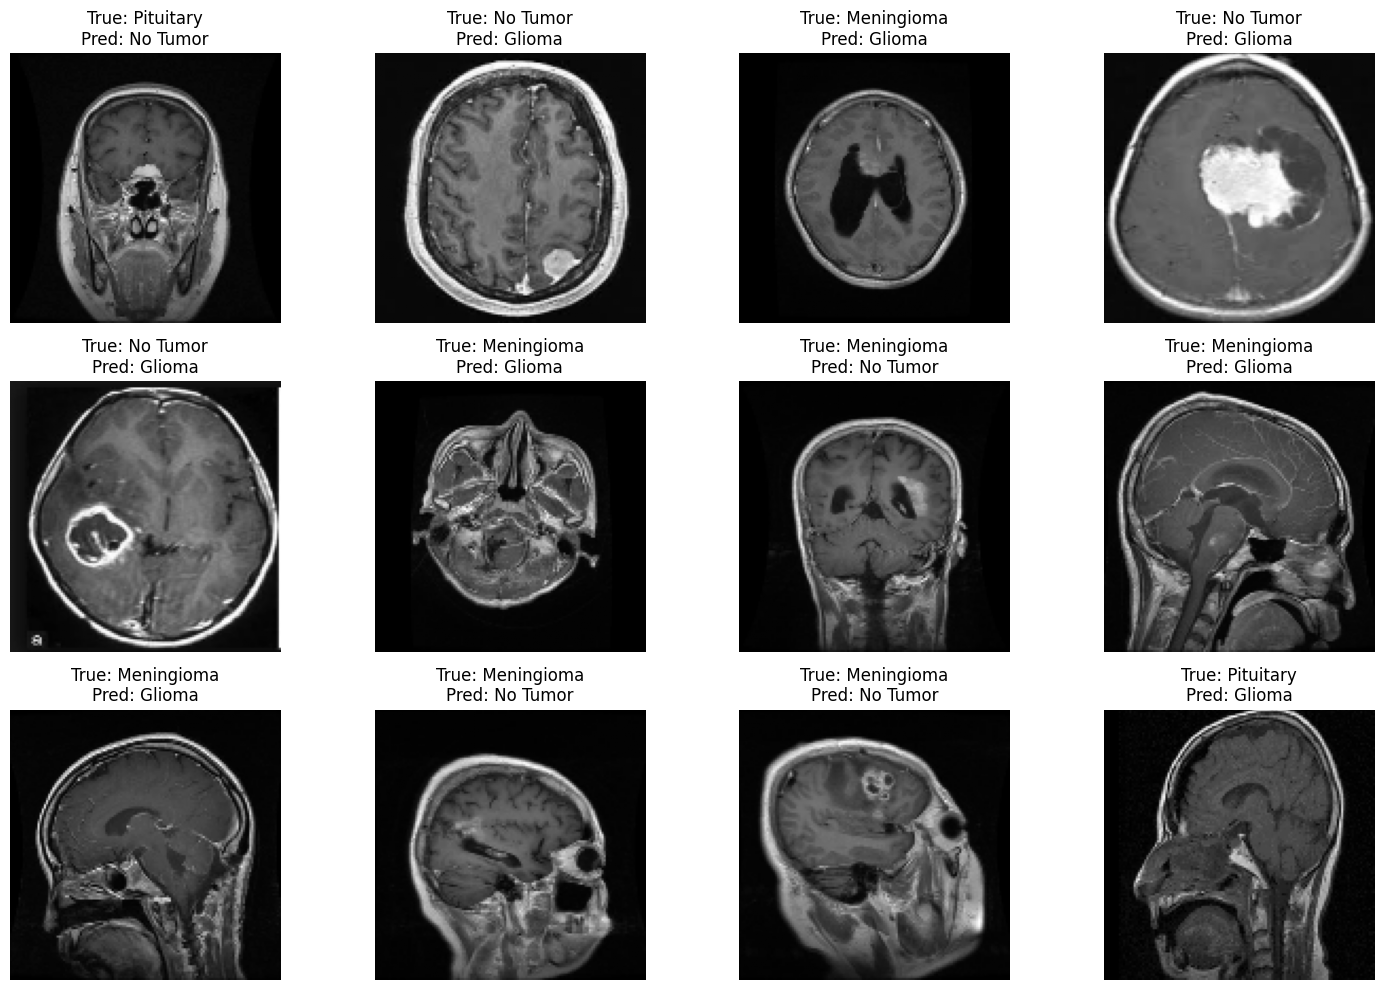

In [71]:
import numpy as np
import matplotlib.pyplot as plt

misclassified = np.where(y_true != y_pred)[0]

print(f"Number of misclassified images: {len(misclassified)}")

plt.figure(figsize=(15,10))

for i, idx in enumerate(misclassified[:12]):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[idx].squeeze(), cmap="gray")
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [72]:
for layer in baseline_model.layers:
    print(layer.name)

data_augmentation
conv2d_8
max_pooling2d_8
conv2d_9
max_pooling2d_9
conv2d_10
max_pooling2d_10
conv2d_11
max_pooling2d_11
flatten_2
dense_4
dropout_2
dense_5


In [73]:
import numpy as np

X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_test_rgb  = np.repeat(X_test, 3, axis=-1)

print(X_train_rgb.shape)
print(X_test_rgb.shape)

(4480, 128, 128, 3)
(1120, 128, 128, 3)


In [74]:
import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model

In [75]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(128,128,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [76]:
base_model.trainable = False

In [77]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

output = Dense(4, activation="softmax")(x)

vgg16_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [78]:
vgg16_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [79]:
vgg16_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [80]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=4,
    min_lr=1e-6
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_vgg16.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [81]:
history_vgg16 = vgg16_model.fit(
    X_train_rgb,
    y_train_cat,
    validation_data=(X_test_rgb, y_test_cat),
    epochs=30,
    batch_size=32,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.3509 - loss: 1.3754 - val_accuracy: 0.6232 - val_loss: 1.0828 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.5696 - loss: 1.0453 - val_accuracy: 0.7304 - val_loss: 0.8950 - learning_rate: 1.0000e-04
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.6808 - loss: 0.8710 - val_accuracy: 0.7598 - val_loss: 0.7831 - learning_rate: 1.0000e-04
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.7413 - loss: 0.7614 - val_accuracy: 0.7786 - val_loss: 0.7077 - learning_rate: 1.0000e-04
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.7598 - loss: 0.6987 - val_accuracy: 0.7937 - val_loss: 0.6524 - learning_rate: 1.0000e-04
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.7821 - loss: 0.6397 - val_accuracy: 0.8036 - val_loss: 0.6113 - learning_rate: 1.0000e-04
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/ste

In [82]:
test_loss, test_acc = vgg16_model.evaluate(
    X_test_rgb,
    y_test_cat,
    verbose=1
)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8679 - loss: 0.3735
Test Accuracy: 0.8679
Test Loss: 0.3735


In [83]:
import numpy as np

y_pred_prob = vgg16_model.predict(X_test_rgb)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step


In [84]:
from sklearn.metrics import classification_report

class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.94      0.91      0.93       280
  meningioma       0.86      0.81      0.83       280
     notumor       0.75      0.80      0.77       280
   pituitary       0.93      0.95      0.94       280

    accuracy                           0.87      1120
   macro avg       0.87      0.87      0.87      1120
weighted avg       0.87      0.87      0.87      1120



In [85]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[256   3  18   3]
 [  1 226  50   3]
 [ 13  30 223  14]
 [  2   4   7 267]]


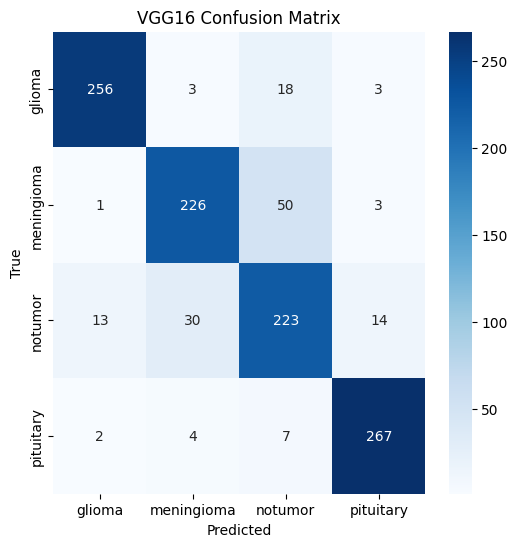

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("VGG16 Confusion Matrix")

plt.show()